In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

In [2]:
# Define all subdirectories in short
short_base = Path('short')

subdirs = {
    'base_linux': short_base / 'base_linux',
    'base_unikernel': short_base / 'base_unikernel',
    'naive_linux': short_base / 'naive-linux',
    'linux_iso': short_base / 'linux_iso',
    'linux_optimized_wo_iso': short_base / 'linux-optimized-wo-iso',
    'optimized_unikernel': short_base / 'optimized_unikernel',
}

config_labels = {
    'base_linux': 'Linux Base',
    'naive_linux': 'Linux Naive',
    'linux_iso': 'Linux ISO',
    'linux_optimized_wo_iso': 'Linux Opt',
    'base_unikernel': 'Unikernel Base',
    'optimized_unikernel': 'Unikernel Opt',
}
# Compatibility alias if referenced with this spelling elsewhere
config_lables = config_labels

print("Available subdirectories:")
for name, path in subdirs.items():
    pretty = config_labels.get(name, name)
    print(f"  {pretty}: {path}")

Available subdirectories:
  Linux Base: short/base_linux
  Unikernel Base: short/base_unikernel
  Linux Naive: short/naive-linux
  Linux ISO: short/linux_iso
  Linux Opt: short/linux-optimized-wo-iso
  Unikernel Opt: short/optimized_unikernel


In [3]:
# Load powermeter measurements (binary_output_*.log files)
powermeter_data = {}

for name, path in subdirs.items():
    powermeter_data[name] = {}
    
    # Get all .log files in the directory
    log_files = sorted(path.glob('binary_output_*.log'))
    
    for log_file in log_files:
        # Extract benchmark name and iteration number from filename
        # e.g., binary_output_crc32_0.log -> benchmark=crc32, iteration=0
        match = re.match(r'binary_output_(.+)_(\d+)\.log', log_file.name)
        if match:
            benchmark = match.group(1)
            iteration = int(match.group(2))
            
            # Initialize benchmark dict if needed
            if benchmark not in powermeter_data[name]:
                powermeter_data[name][benchmark] = {}
            
            # Load the log file
            try:
                df = pd.read_csv(log_file)
                powermeter_data[name][benchmark][iteration] = df
            except Exception as e:
                print(f"Error loading {log_file}: {e}")

# Print summary
print("Powermeter data summary:")
for config_name, benchmarks in powermeter_data.items():
    total_files = sum(len(iterations) for iterations in benchmarks.values())
    print(f"  {config_name}: {len(benchmarks)} benchmarks, {total_files} total files")

Powermeter data summary:
  base_linux: 9 benchmarks, 450 total files
  base_unikernel: 9 benchmarks, 450 total files
  naive_linux: 9 benchmarks, 450 total files
  linux_iso: 9 benchmarks, 450 total files
  linux_optimized_wo_iso: 9 benchmarks, 450 total files
  optimized_unikernel: 9 benchmarks, 450 total files


In [4]:
# Display sample powermeter data
config = 'base_linux'
benchmark = list(powermeter_data[config].keys())[0] if powermeter_data[config] else None
iteration = 0

if config in powermeter_data and benchmark in powermeter_data[config]:
    if iteration in powermeter_data[config][benchmark]:
        print(f"Sample powermeter data from {config} / {benchmark} / iteration {iteration}:")
        print(powermeter_data[config][benchmark][iteration].head(10))
        print(f"\nShape: {powermeter_data[config][benchmark][iteration].shape}")
    else:
        print(f"Iteration {iteration} not found")
else:
    print(f"Config or benchmark not found")

Sample powermeter data from base_linux / crc32 / iteration 0:
     unix_timestamp  active_power (mW)
0  1773748423711634              52150
1  1773748423754680              50320
2  1773748423797833              46760
3  1773748423840637              46720

Shape: (4, 2)


In [5]:
# Display structure of powermeter data
print("Benchmarks found per configuration:")
for config_name, benchmarks in powermeter_data.items():
    benchmark_list = sorted(benchmarks.keys())
    iterations = [len(benchmarks[b]) for b in benchmark_list]
    print(f"\n{config_name}:")
    print(f"  Benchmarks: {benchmark_list}")
    print(f"  Iterations per benchmark: {iterations[0] if iterations else 0} (first benchmark)")

Benchmarks found per configuration:

base_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

base_unikernel:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

naive_linux:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

linux_iso:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

linux_optimized_wo_iso:
  Benchmarks: ['crc32', 'cubic', 'dijkstra', 'fdct', 'fir', 'matmult-float', 'matmult-int', 'nettle-sha256', 'rijndael']
  Iterations per benchmark: 50 (first benchmark)

optimized_unikernel:
  Benchmark

In [6]:
# Load PC measurements (unikernel_output.csv from each directory)
pc_data = {}

for name, path in subdirs.items():
    csv_file = path / 'unikernel_output.csv'
    if csv_file.exists():
        df = pd.read_csv(csv_file)
        pc_data[name] = df
        print(f"Loaded {name}: {len(df)} rows, {len(df.columns)} columns")
    else:
        print(f"Warning: {csv_file} not found")

print(f"\nTotal configurations loaded: {len(pc_data)}")

Loaded base_linux: 451 rows, 21 columns
Loaded base_unikernel: 450 rows, 21 columns
Loaded naive_linux: 450 rows, 21 columns
Loaded linux_iso: 450 rows, 21 columns
Loaded linux_optimized_wo_iso: 450 rows, 21 columns
Loaded optimized_unikernel: 450 rows, 21 columns

Total configurations loaded: 6


In [7]:
# Display sample PC data for one configuration
if pc_data:
    first_config = list(pc_data.keys())[0]
    print(f"Sample PC data from {first_config}:")
    print(pc_data[first_config].head())

Sample PC data from base_linux:
  benchmark   cpu_cycles  cycles_start    cycles_end      time_ns     time_ms  \
0     crc32  436197622.0  1.295499e+12  1.295936e+12  141083112.0  141.083112   
1     crc32  435259138.0  1.295936e+12  1.296371e+12  140784823.0  140.784823   
2     crc32  435417092.0  1.296372e+12  1.296807e+12  140829360.0  140.829360   
3     crc32  435382203.0  1.296807e+12  1.297243e+12  140816964.0  140.816964   
4     crc32  435247899.0  1.297243e+12  1.297678e+12  140774667.0  140.774667   

   cooldown_ms  temp_before  temp_after  pkg_temp_before  ...  pkg_joules  \
0        0.010         45.0        42.0             45.0  ...    2.489609   
1        0.009         42.0        42.0             42.0  ...    2.468292   
2        0.008         42.0        42.0             42.0  ...    2.483093   
3        0.008         42.0        43.0             42.0  ...    2.466888   
4        0.008         43.0        42.0             43.0  ...    2.485077   

     pkg_mJ  pp0_j

In [8]:
# Calculate energy consumption from powermeter data and compare with pkg energy
# Energy = Average Power (W) × Time (s)

energy_results = []

for config_name in subdirs.keys():
    # Get PC data for this config
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    # Get unique benchmarks from PC data
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get PC measurements for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        # Skip if no data found for this benchmark
        if len(pc_bench) == 0:
            continue
        
        # Calculate mean and std for pkg energy from PC data (in Joules)
        pkg_energies = pc_bench['pkg_joules'].values
        mean_pkg_joules = pkg_energies.mean()
        std_pkg_joules = pkg_energies.std()
        mean_time_ms = pc_bench['cpu_cycles'].mean() / 3.1e6  # Convert cycles to ms at 3.1 GHz
        
        # Calculate energy from powermeter data if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                # Skip empty or very small DataFrames (need at least 2 points for time span)
                if len(pm_df) < 2:
                    continue
                
                # Skip if iteration index is out of bounds
                if iteration >= len(pc_bench):
                    continue
                    
                # Get average power in Watts (convert mW to W)
                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                
                # Get time span from CPU cycles
                cpu_cycles = pc_bench.iloc[iteration]['cpu_cycles']
                time_span_s = cpu_cycles / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                
                # Calculate energy in Joules
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            mean_powermeter_energy = np.mean(powermeter_energies) if powermeter_energies else None
            std_powermeter_energy = np.std(powermeter_energies) if powermeter_energies else None
        else:
            mean_powermeter_energy = None
            std_powermeter_energy = None
        
        energy_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_energy_j': mean_pkg_joules,
            'pkg_energy_std': std_pkg_joules,
            'powermeter_energy_j': mean_powermeter_energy,
            'powermeter_energy_std': std_powermeter_energy,
            'time_ms': mean_time_ms
        })

# Convert to DataFrame for easier plotting
energy_df = pd.DataFrame(energy_results)
print(f"Energy analysis ready: {len(energy_df)} benchmark-config combinations")
print(energy_df.head(10))

Energy analysis ready: 54 benchmark-config combinations
           config      benchmark  pkg_energy_j  pkg_energy_std  \
0      base_linux          crc32      2.480921        0.044711   
1      base_linux          cubic      2.502054        0.008828   
2      base_linux       dijkstra      2.638063        0.037391   
3      base_linux           fdct      2.634115        0.019622   
4      base_linux            fir      2.524359        0.016352   
5      base_linux  matmult-float      3.111361        0.033926   
6      base_linux    matmult-int      2.867104        0.044504   
7      base_linux  nettle-sha256      3.329959        0.026128   
8      base_linux       rijndael      3.136191        0.035225   
9  base_unikernel          crc32      2.200740        0.008185   

   powermeter_energy_j  powermeter_energy_std     time_ms  
0             6.404510               0.148995  140.596674  
1             6.175476               0.038608  130.180339  
2             5.950141               

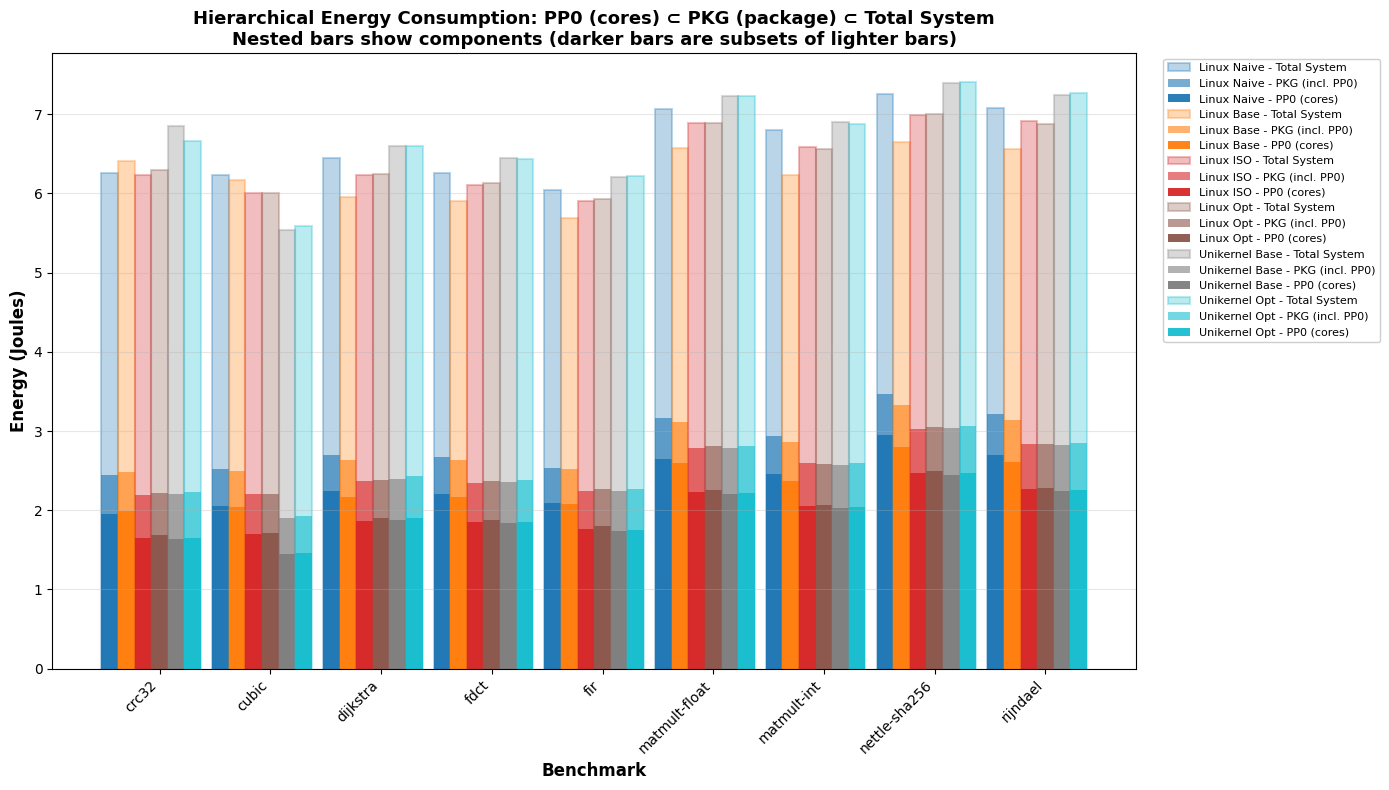

In [9]:
# Create plot showing hierarchical energy consumption: PP0 ⊂ PKG ⊂ Total System Energy
# PP0 (CPU cores) is a subset of PKG (CPU package), which is a subset of total system energy
fig, ax = plt.subplots(figsize=(14, 8))

# Get unique benchmarks and configs (filter out NaN values)
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
# Filter to only configs present in data, maintaining the desired order
configs = [c for c in config_order if c in energy_df['config'].unique()]

# Use global config label mapping
config_names = config_labels

# Set up x positions for grouped bars
x = np.arange(len(benchmarks))
width = 0.15  # Width of each bar
colors = plt.cm.tab10(np.linspace(0, 0.9, len(configs)))

# Plot bars for each configuration
for i, config in enumerate(configs):
    config_data = energy_df[energy_df['config'] == config]
    short_name = config_names.get(config, config)
    
    # Prepare data aligned with benchmark order
    pm_energies = []
    pkg_energies = []
    pp0_energies = []
    
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0:
            pm_val = bench_data['powermeter_energy_j'].values[0]
            pkg_val = bench_data['pkg_energy_j'].values[0]
            # Get PP0 data from pc_data
            if config in pc_data:
                pc_bench = pc_data[config][pc_data[config]['benchmark'] == bench]
                pp0_val = pc_bench['pp0_joules'].mean() if len(pc_bench) > 0 else 0
            else:
                pp0_val = 0
            
            # Handle None values
            pm_energies.append(pm_val if pd.notna(pm_val) else 0)
            pkg_energies.append(pkg_val if pd.notna(pkg_val) else 0)
            pp0_energies.append(pp0_val if pd.notna(pp0_val) else 0)
        else:
            pm_energies.append(0)
            pkg_energies.append(0)
            pp0_energies.append(0)
    
    # Plot as nested bars to show hierarchy:
    # - Total system energy (lightest, outermost)
    # - PKG = CPU cores (PP0) + uncore components (middle layer)
    # - PP0 = CPU cores only (darkest, innermost)
    offset = (i - len(configs)/2) * width
    ax.bar(x + offset, pm_energies, width, label=f'{short_name} - Total System', 
           color=colors[i], alpha=0.3, edgecolor=colors[i], linewidth=1.5)
    
    # PKG contains PP0 plus uncore (memory controller, L3 cache, etc.)
    ax.bar(x + offset, pkg_energies, width, label=f'{short_name} - PKG (incl. PP0)', 
           color=colors[i], alpha=0.6)
    
    # PP0 is a component within PKG (CPU cores only)
    ax.bar(x + offset, pp0_energies, width, label=f'{short_name} - PP0 (cores)', 
           color=colors[i], alpha=0.95)

ax.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
ax.set_title('Hierarchical Energy Consumption: PP0 (cores) ⊂ PKG (package) ⊂ Total System\nNested bars show components (darker bars are subsets of lighter bars)', 
             fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(benchmarks, rotation=45, ha='right')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8, ncol=1, framealpha=0.95)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# Calculate coefficient of variation (CV) for energy measurements
# CV = (std / mean) * 100%

cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PKG energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pkg_energies = pc_bench['pkg_joules'].values
        
        # Calculate PKG CV
        if len(pkg_energies) > 1:
            pkg_cv = (pkg_energies.std() / pkg_energies.mean()) * 100
        else:
            pkg_cv = None
        
        # Calculate powermeter CV if available
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            powermeter_energies = []
            
            for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                if len(pm_df) < 2:
                    continue
                
                # Skip if iteration index is out of bounds
                if iteration >= len(pc_bench):
                    continue
                
                time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz

                avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                energy_j = avg_power_w * time_span_s
                powermeter_energies.append(energy_j)
            
            if len(powermeter_energies) > 1:
                pm_cv = (np.std(powermeter_energies) / np.mean(powermeter_energies)) * 100
            else:
                pm_cv = None
        else:
            pm_cv = None
        
        cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pkg_cv': pkg_cv,
            'powermeter_cv': pm_cv
        })

# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)
print(f"CV analysis ready: {len(cv_df)} benchmark-config combinations")
print(cv_df.head(10))

CV analysis ready: 55 benchmark-config combinations
       config      benchmark    pkg_cv  powermeter_cv
0  base_linux          crc32  1.802193       2.326404
1  base_linux          cubic  0.352817       0.625189
2  base_linux       dijkstra  1.417349       3.435272
3  base_linux           fdct  0.744912       2.585026
4  base_linux            fir  0.647754       2.303651
5  base_linux  matmult-float  1.090394       2.230922
6  base_linux    matmult-int  1.552225       3.695965
7  base_linux  nettle-sha256  0.784636       2.182532
8  base_linux       rijndael  1.123193       2.181369
9  base_linux            NaN       NaN            NaN


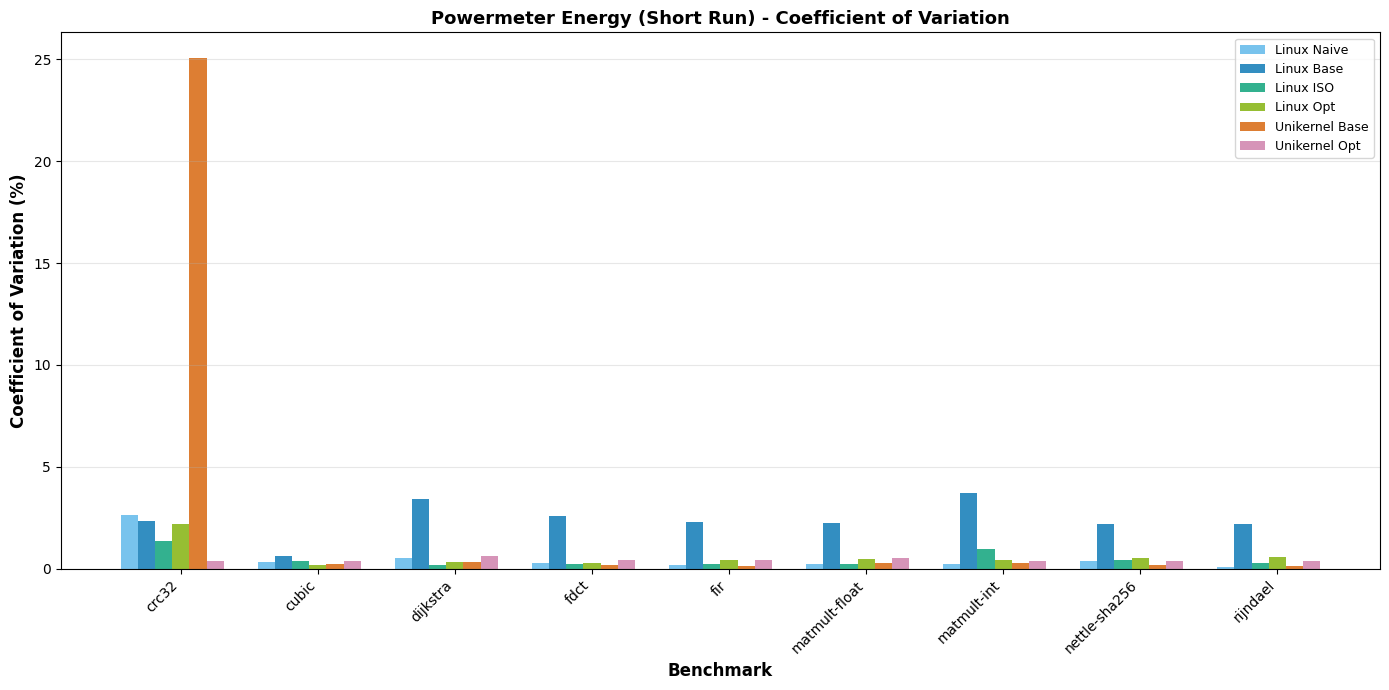

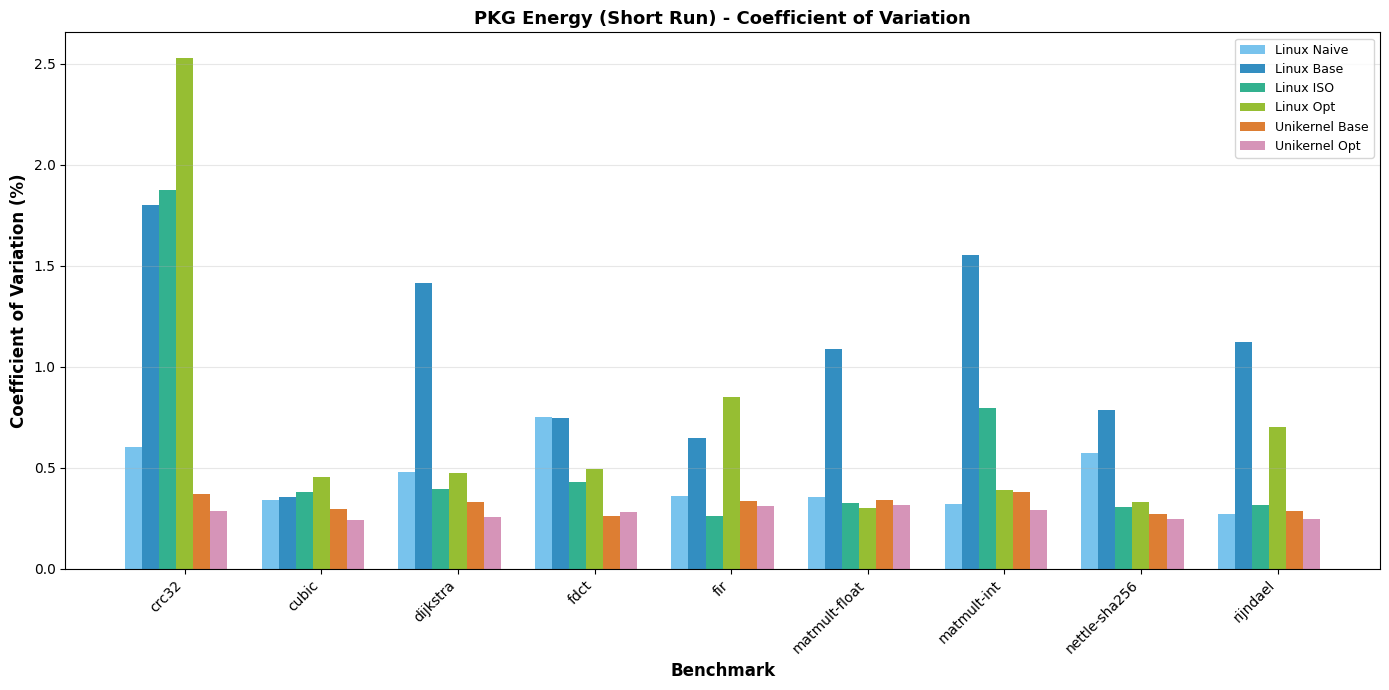

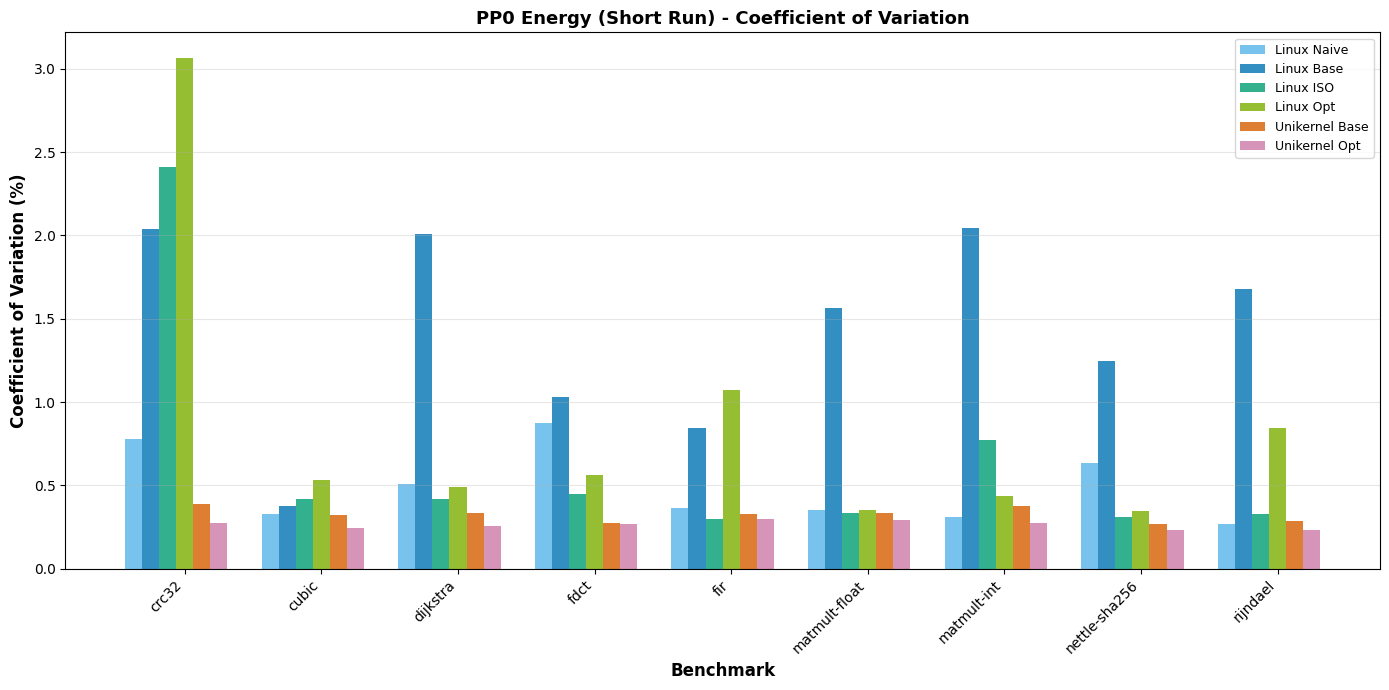

In [19]:
# Create three separate plots for coefficient of variation
# Get unique benchmarks and configs
benchmarks = sorted([b for b in cv_df['benchmark'].unique() if pd.notna(b)])

# Define custom order for configs
config_order = [
    'naive_linux',
    'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in cv_df['config'].unique()]

# Set up x positions with extra spacing between benchmark groups
x = np.arange(len(benchmarks)) * 1.2
width = 0.15
config_colors = {
    'base_linux': '#0072B2',
    'naive_linux': '#56B4E9',
    'linux_iso': '#009E73',
    'linux_optimized_wo_iso': '#7CAE00',
    'base_unikernel': '#D55E00',
    'optimized_unikernel': '#CC79A7'
}


# Plot 1: Powermeter CV
fig1, ax1 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_df[cv_df['config'] == config]
    display_name = config_labels.get(config, config)
    
    pm_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['powermeter_cv'].values[0]):
            pm_cvs.append(bench_data['powermeter_cv'].values[0])
        else:
            pm_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax1.bar(x + offset, pm_cvs, width, label=display_name, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax1.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax1.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax1.set_title('Powermeter Energy (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(benchmarks, rotation=45, ha='right')
ax1.legend(fontsize=9)
ax1.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: PKG CV
fig2, ax2 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = cv_df[cv_df['config'] == config]
    display_name = config_labels.get(config, config)
    
    pkg_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pkg_cv'].values[0]):
            pkg_cvs.append(bench_data['pkg_cv'].values[0])
        else:
            pkg_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax2.bar(x + offset, pkg_cvs, width, label=display_name, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax2.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax2.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax2.set_title('PKG Energy (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(benchmarks, rotation=45, ha='right')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: PP0 CV
# Calculate PP0 CV results
pp0_cv_results = []

for config_name in subdirs.keys():
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    benchmarks_in_config = pc_df['benchmark'].unique()
    
    for benchmark in benchmarks_in_config:
        # Get all PP0 energy values for this benchmark
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        pp0_energies = pc_bench['pp0_joules'].values
        
        # Calculate PP0 CV
        if len(pp0_energies) > 1:
            pp0_cv = (pp0_energies.std() / pp0_energies.mean()) * 100
        else:
            pp0_cv = None
        
        pp0_cv_results.append({
            'config': config_name,
            'benchmark': benchmark,
            'pp0_cv': pp0_cv
        })

# Convert to DataFrame
pp0_cv_df = pd.DataFrame(pp0_cv_results)

fig3, ax3 = plt.subplots(figsize=(14, 7))

for i, config in enumerate(configs):
    config_data = pp0_cv_df[pp0_cv_df['config'] == config]
    display_name = config_labels.get(config, config)
    
    pp0_cvs = []
    for bench in benchmarks:
        bench_data = config_data[config_data['benchmark'] == bench]
        if len(bench_data) > 0 and pd.notna(bench_data['pp0_cv'].values[0]):
            pp0_cvs.append(bench_data['pp0_cv'].values[0])
        else:
            pp0_cvs.append(0)
    
    offset = (i - len(configs)/2) * width
    ax3.bar(x + offset, pp0_cvs, width, label=display_name, color=config_colors.get(config, '#7f7f7f'), alpha=0.8)

ax3.set_xlabel('Benchmark', fontsize=12, fontweight='bold')
ax3.set_ylabel('Coefficient of Variation (%)', fontsize=12, fontweight='bold')
ax3.set_title('PP0 Energy (Short Run) - Coefficient of Variation', fontsize=13, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(benchmarks, rotation=45, ha='right')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


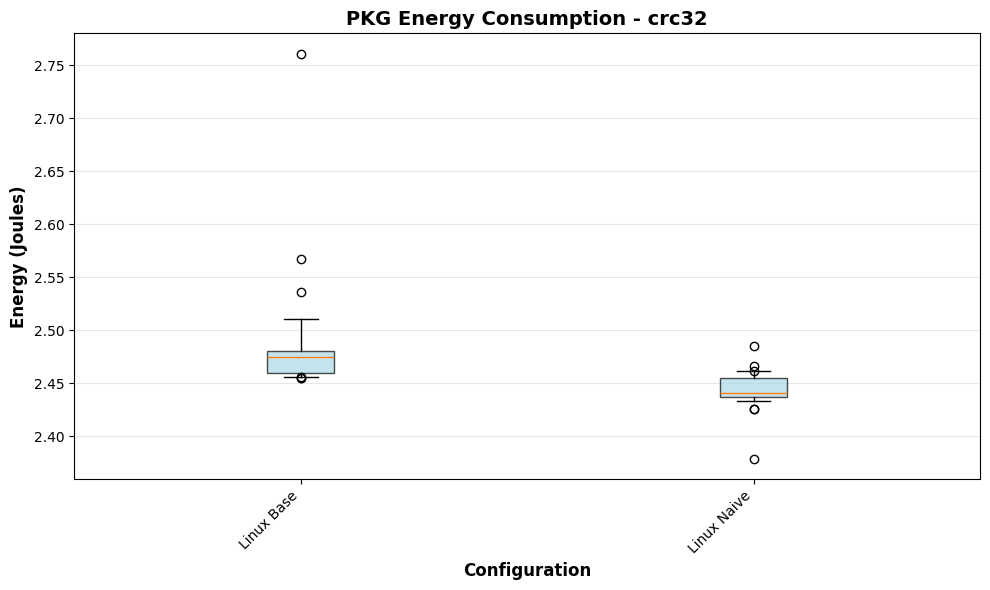

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


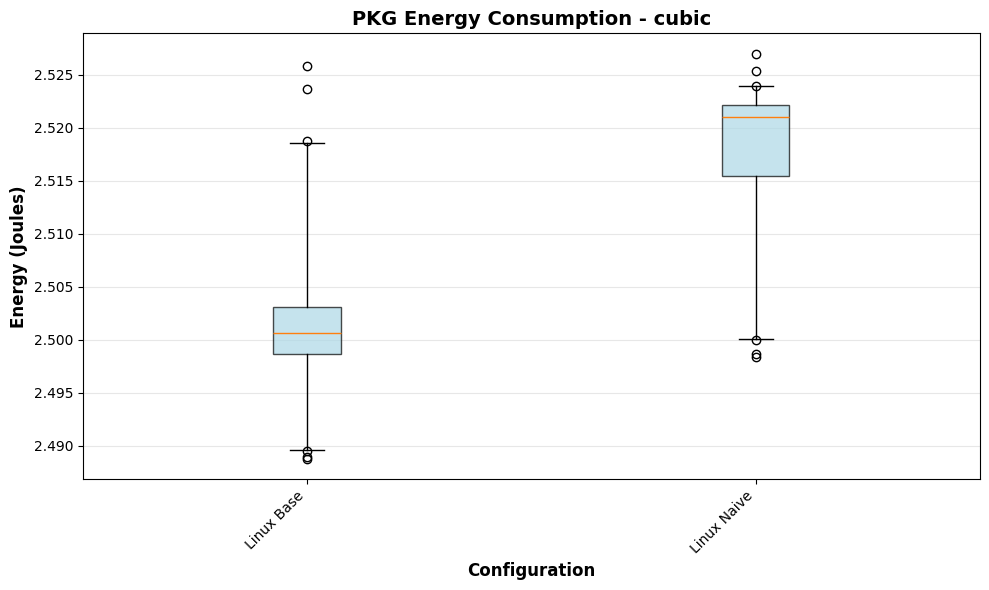

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


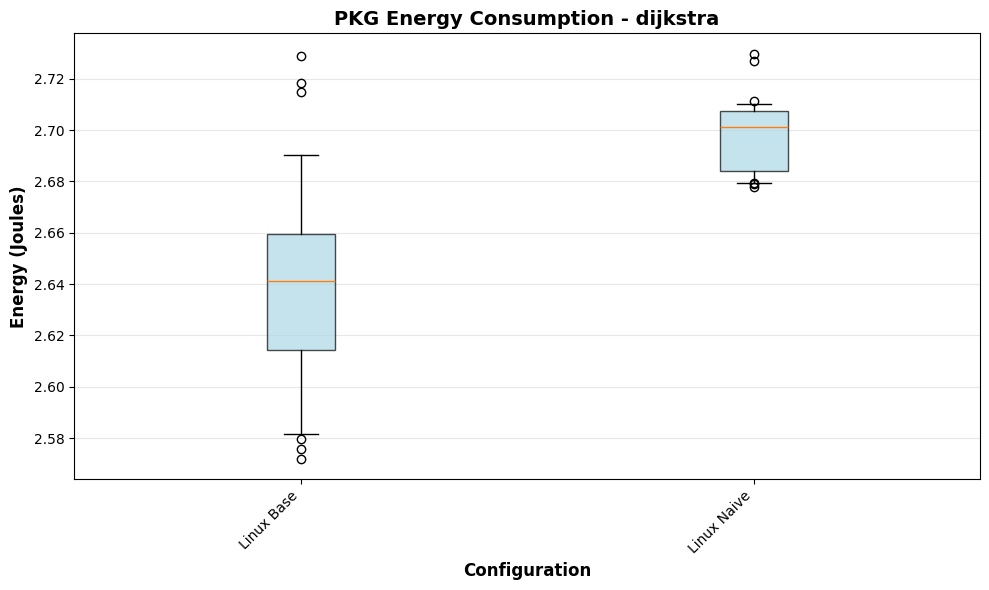

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


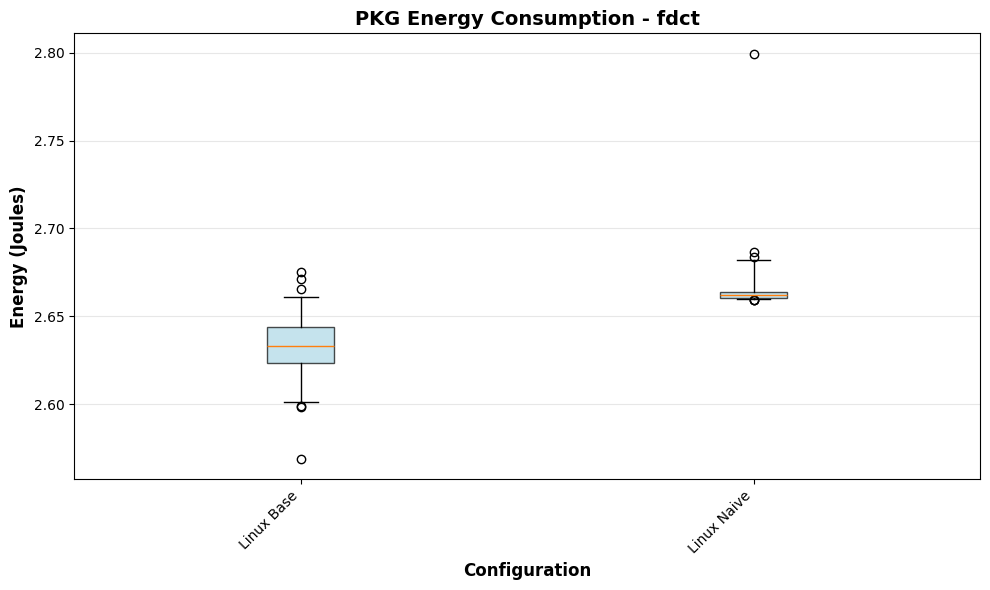

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


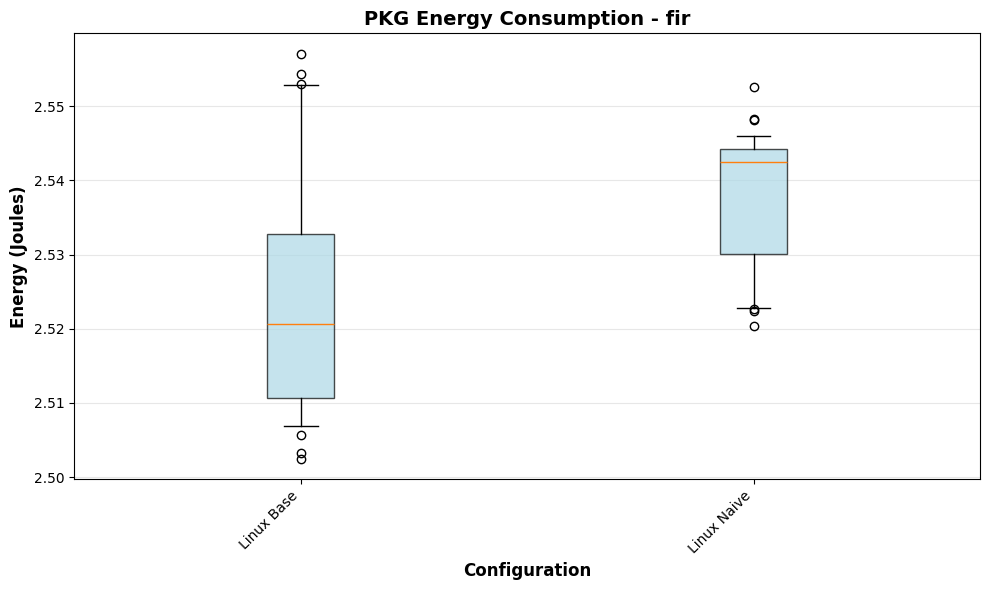

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


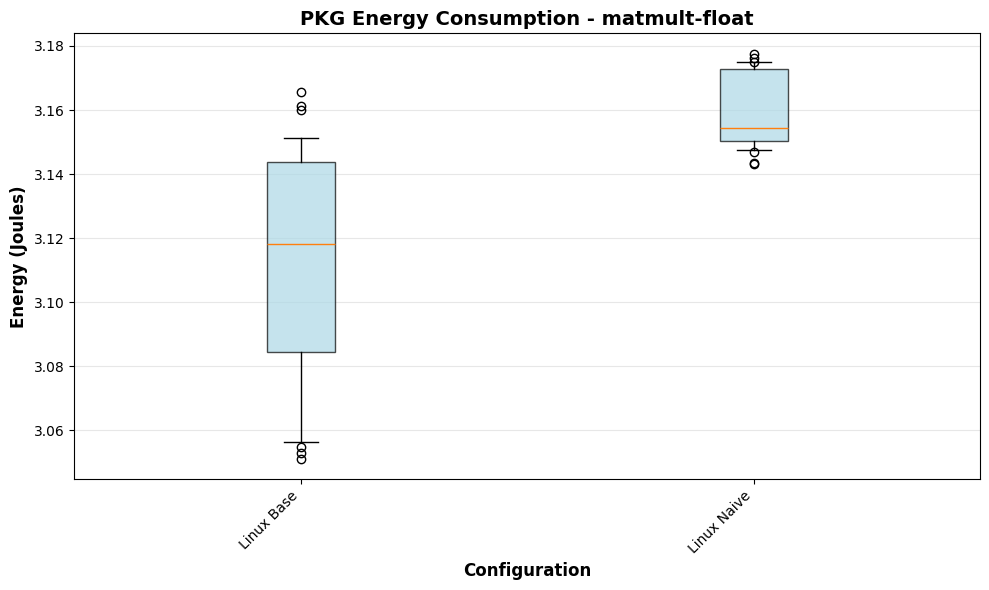

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


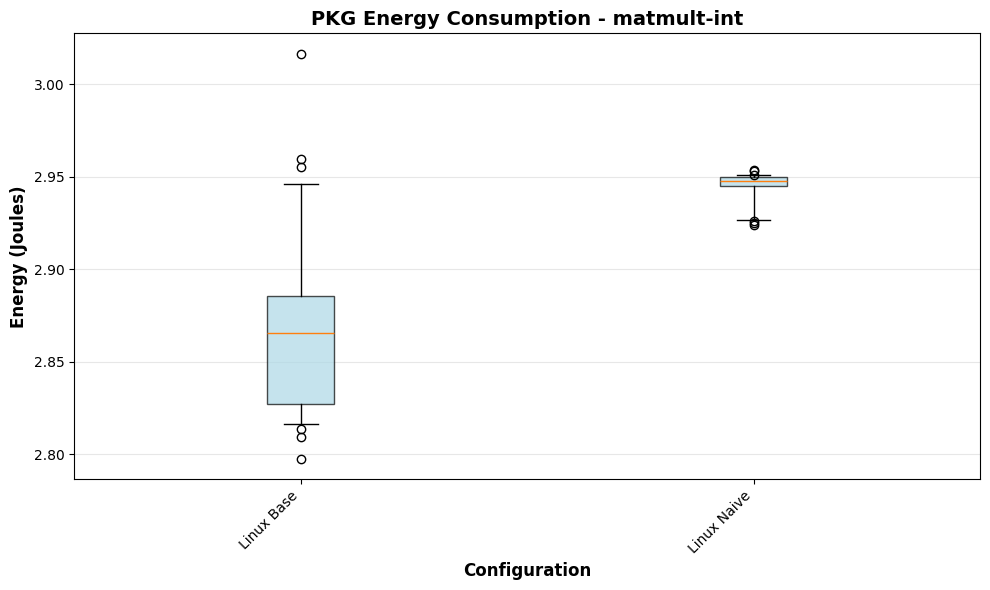

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


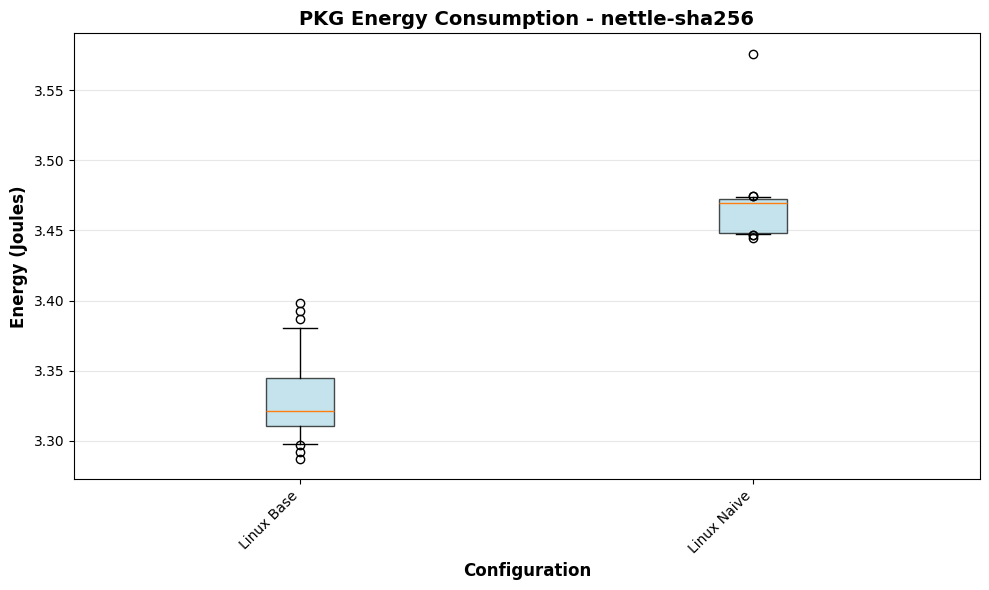

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/1845706880.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


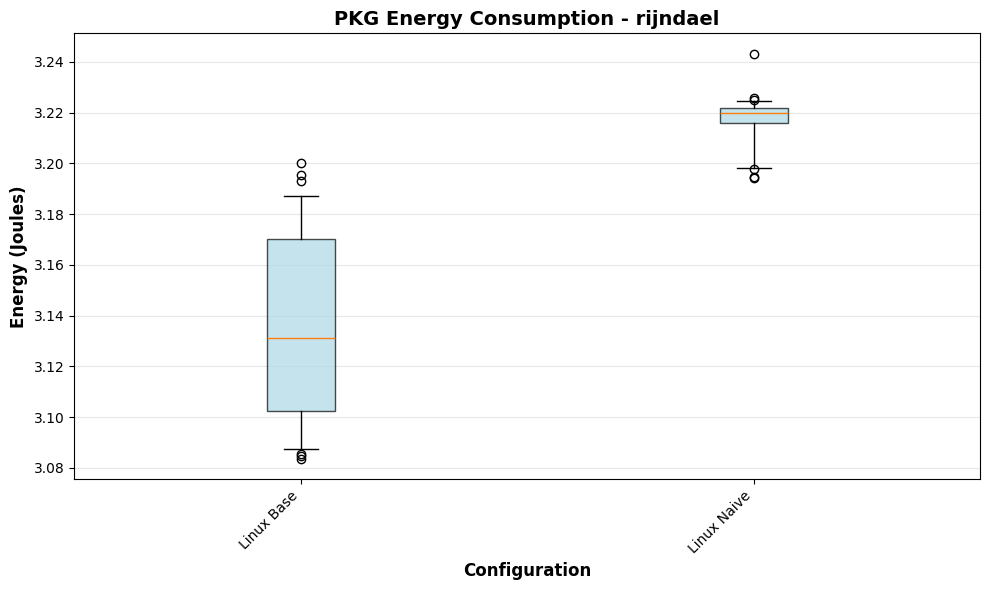

In [20]:
# Boxplot for PKG energy consumption per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'base_linux',
    'naive_linux',
    # 'linux_iso',
    # 'linux_optimized_wo_iso',
    # 'base_unikernel',
    # 'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pkg_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PKG Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


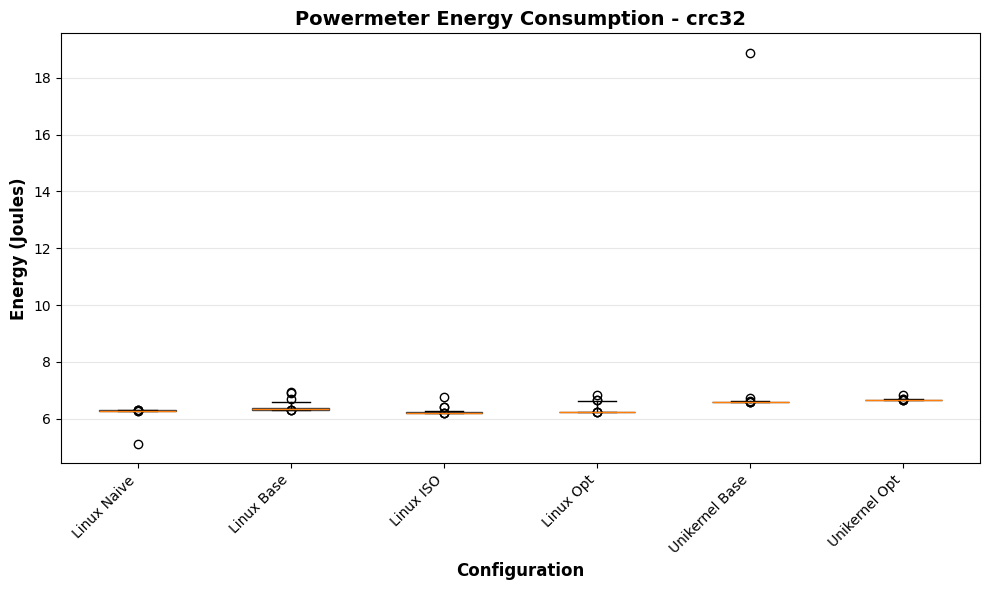

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


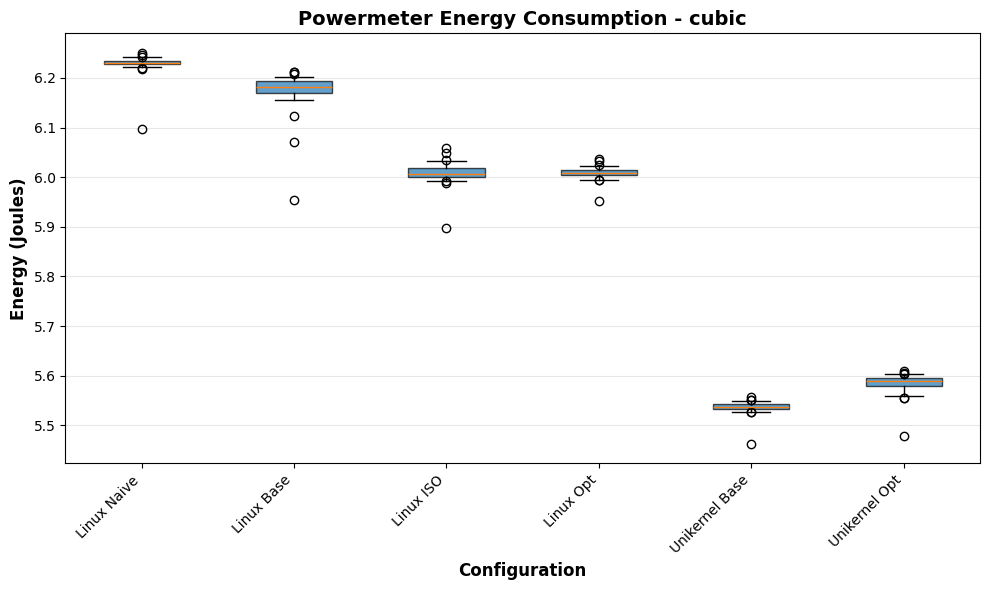

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


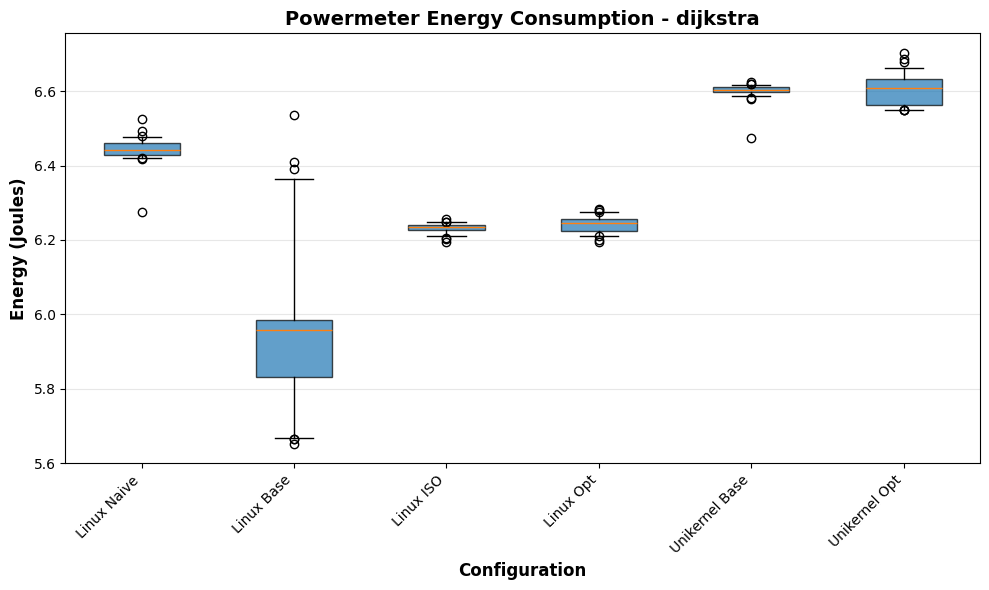

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


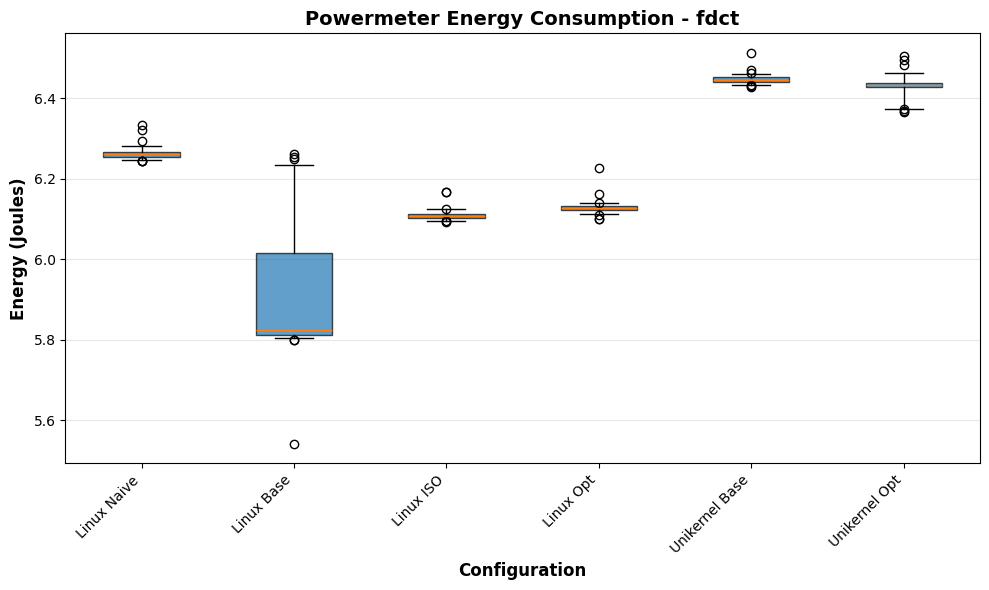

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


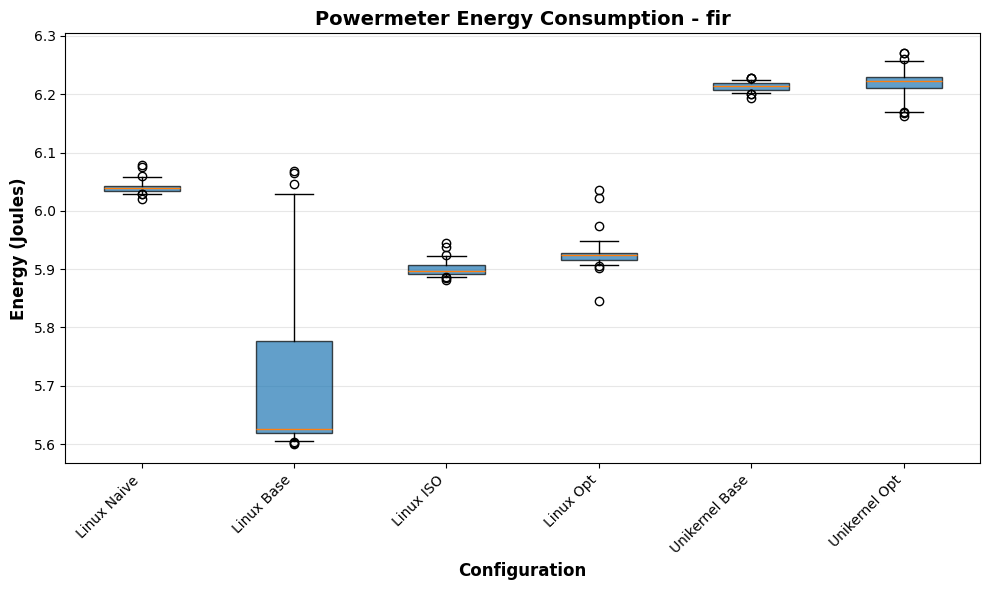

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


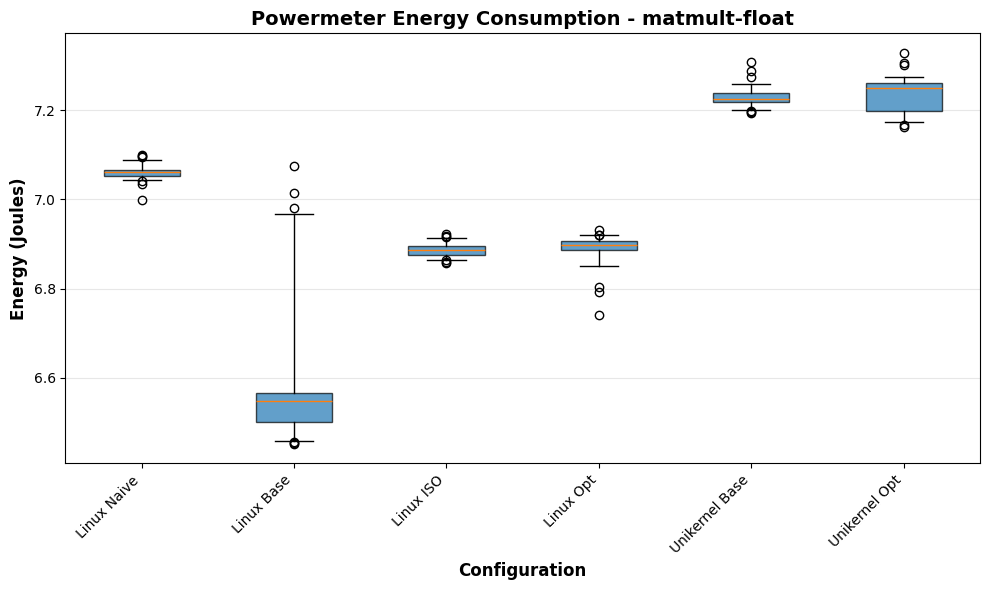

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


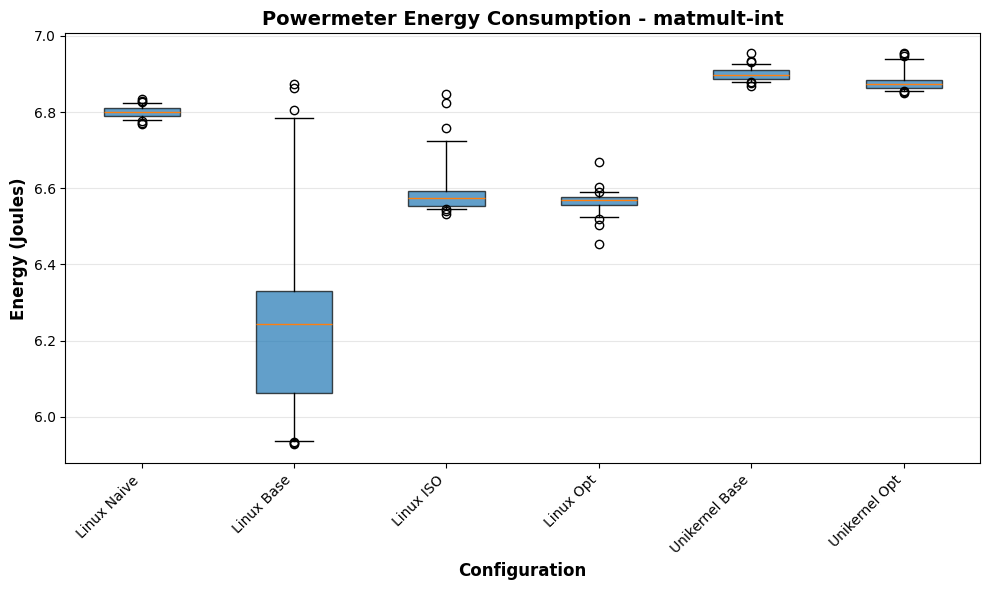

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


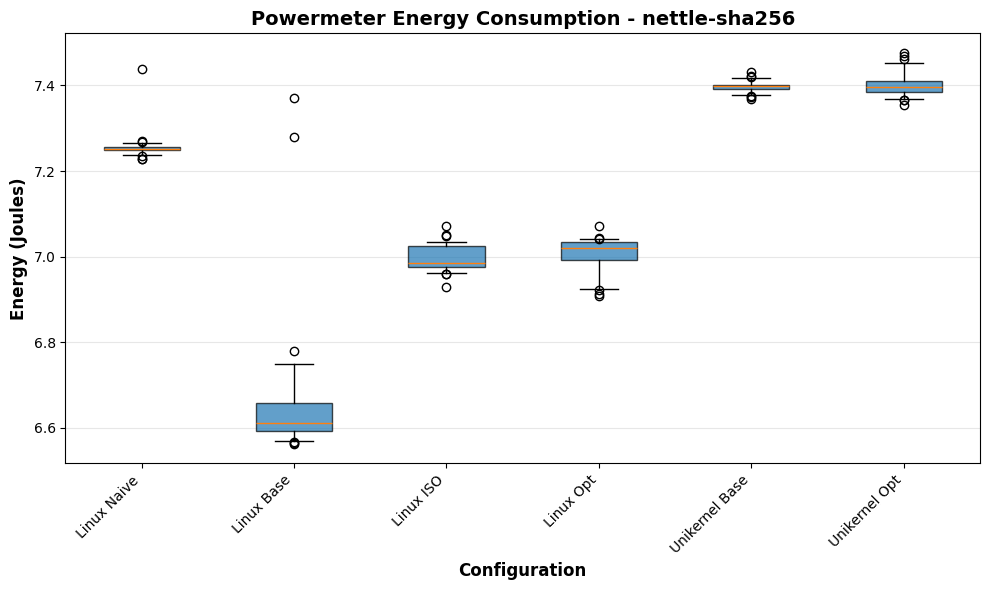

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/2284371597.py:51: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


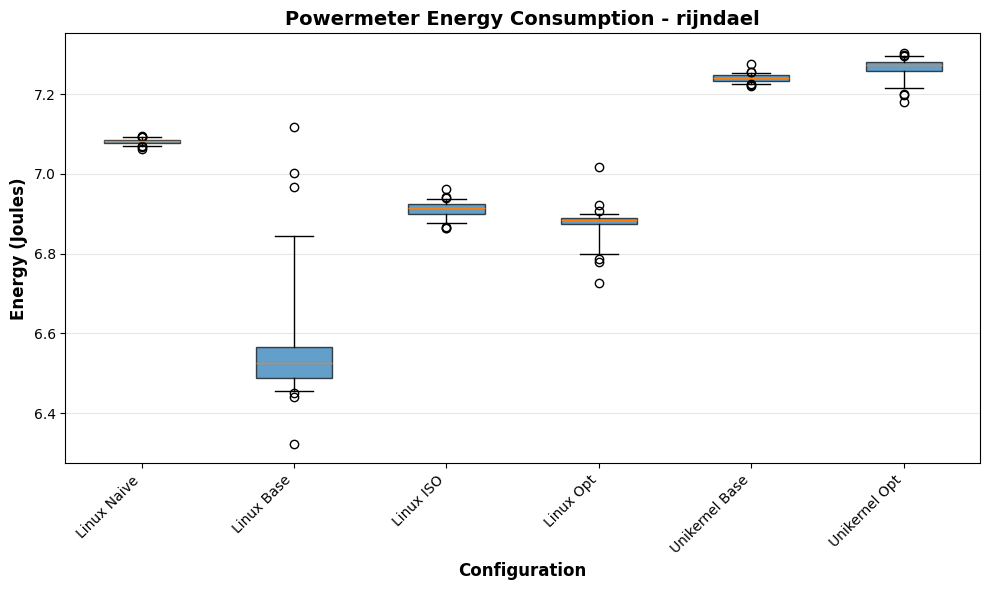

In [21]:
# Boxplot for powermeter energy consumption per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'naive_linux',
    'base_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        bench_data = []
        
        # Get powermeter data for this config and benchmark
        if config_name in powermeter_data and benchmark in powermeter_data[config_name]:
            if config_name in pc_data:
                pc_df = pc_data[config_name]
                pc_bench = pc_df[pc_df['benchmark'] == benchmark]
                
                for iteration, pm_df in powermeter_data[config_name][benchmark].items():
                    if len(pm_df) < 2:
                        continue
                    
                    if iteration < len(pc_bench):
                        time_span_s = pc_bench.iloc[iteration]['cpu_cycles'] / 3.1e9  # Convert cycles to seconds at 3.1 GHz
                        avg_power_w = pm_df['active_power (mW)'].mean() / 1000.0
                        energy_j = avg_power_w * time_span_s
                        bench_data.append(energy_j)
        
        if bench_data:
            data_to_plot.append(bench_data)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'Powermeter Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


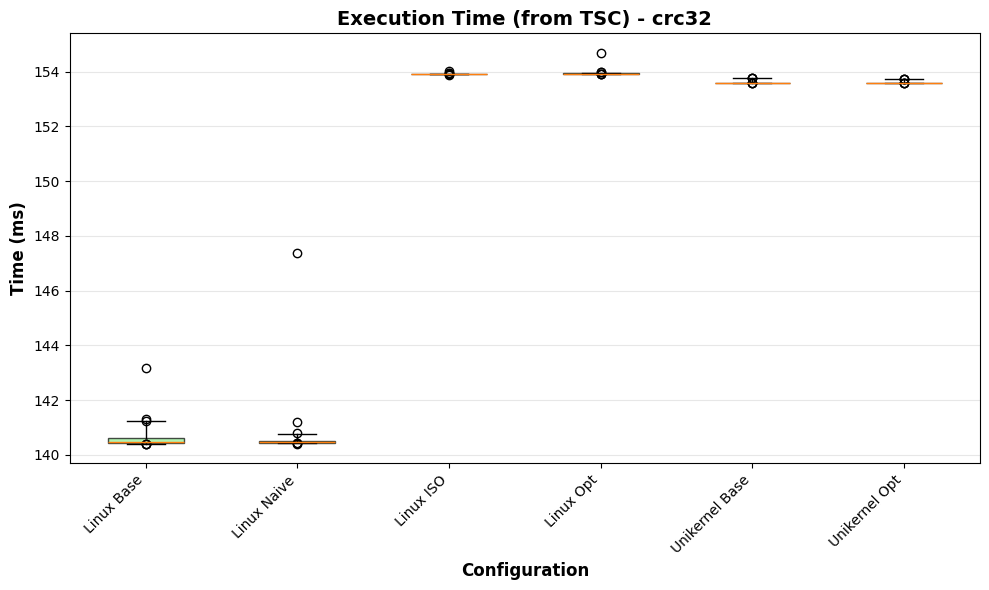

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


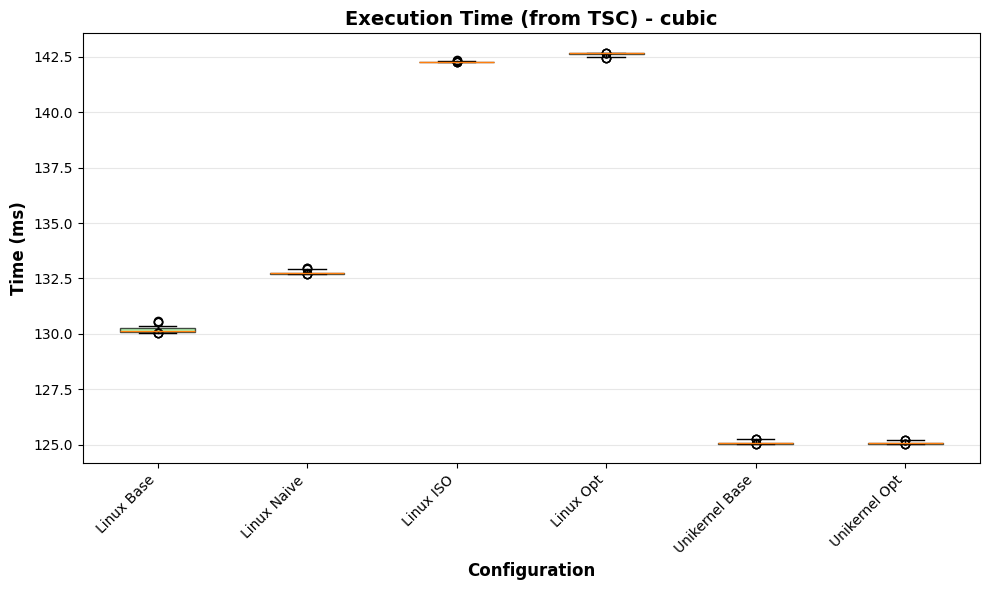

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


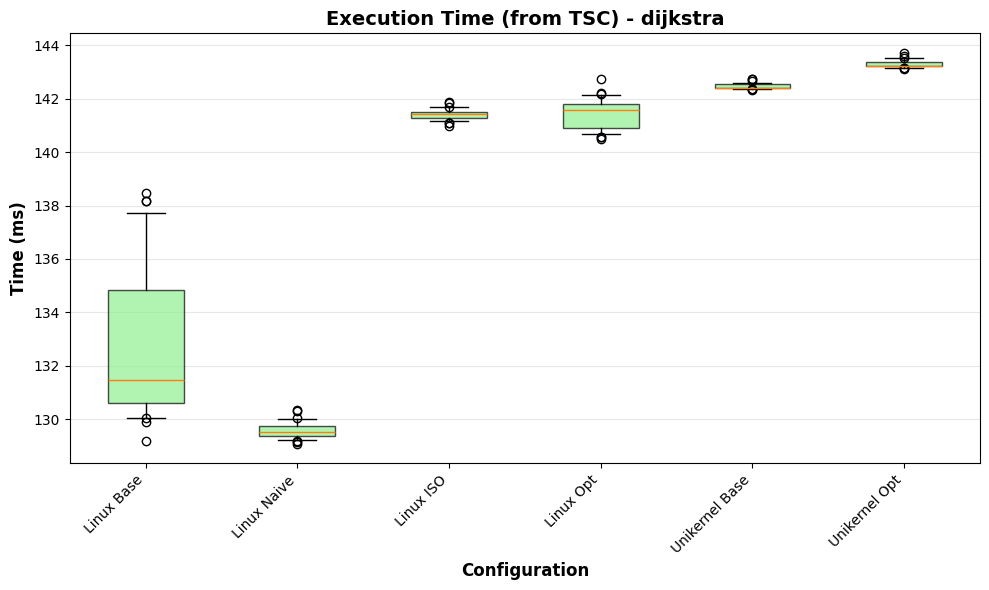

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


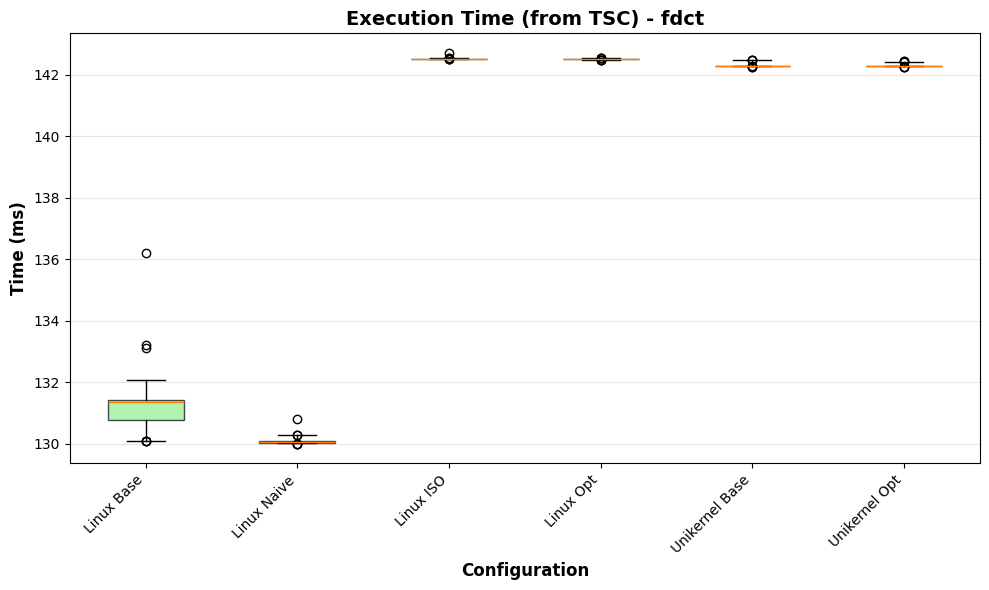

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


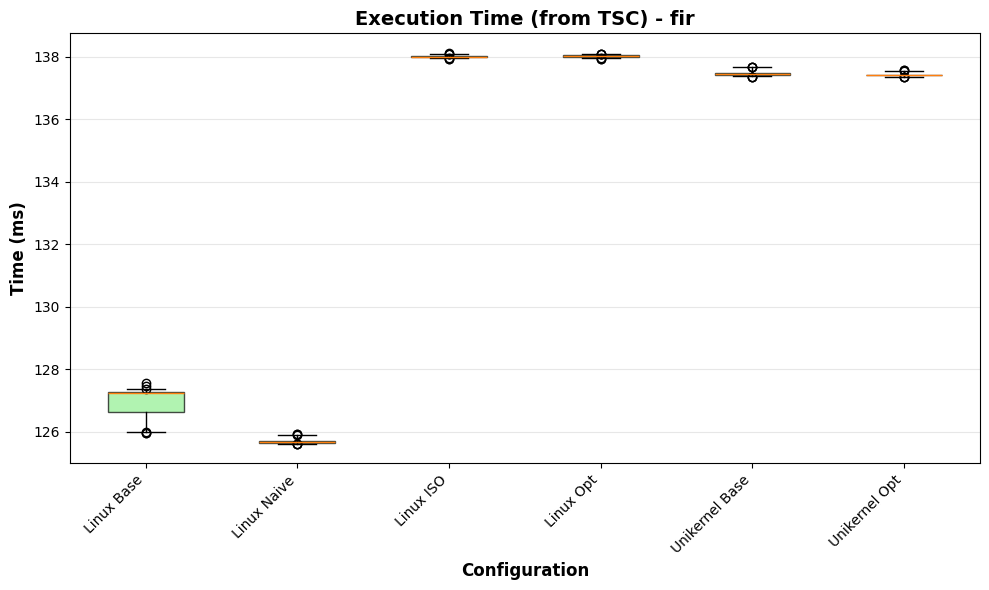

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


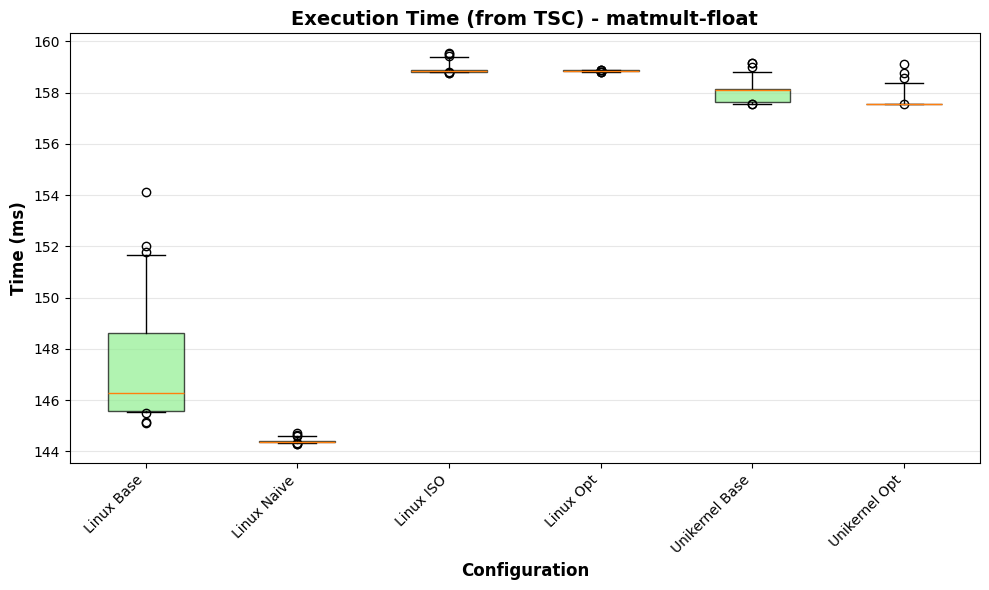

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


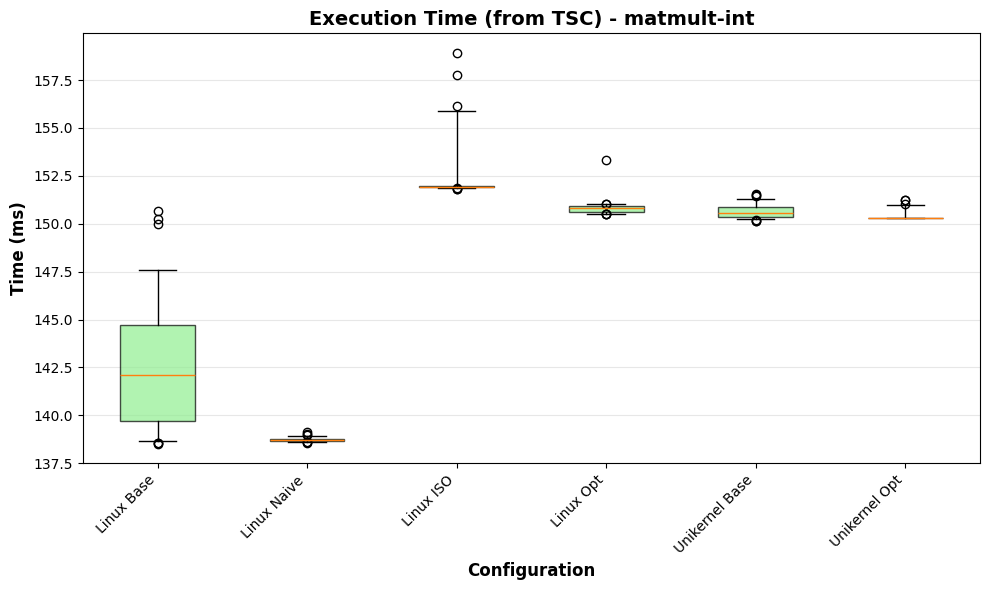

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


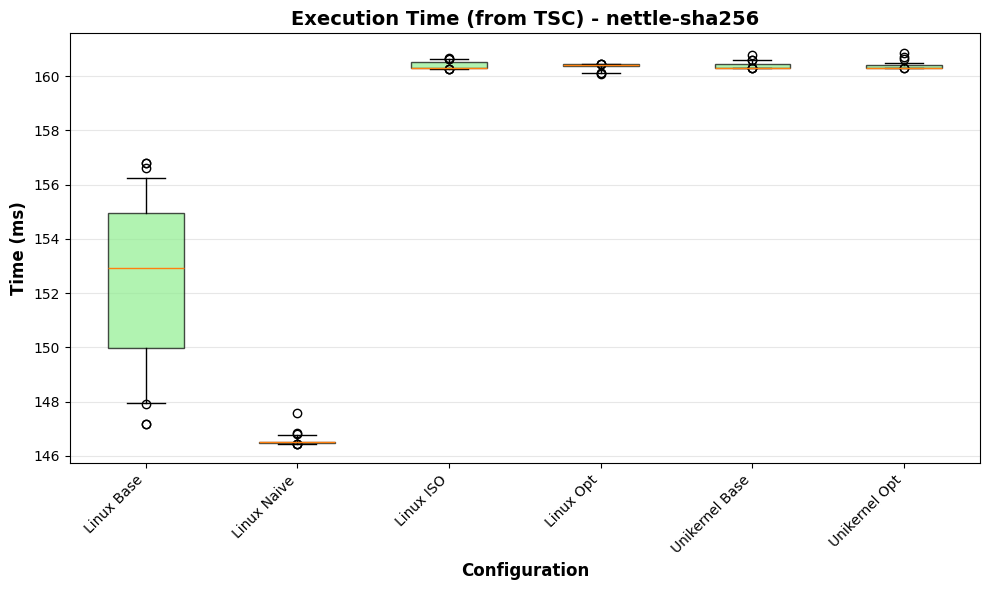

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/3347095064.py:42: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


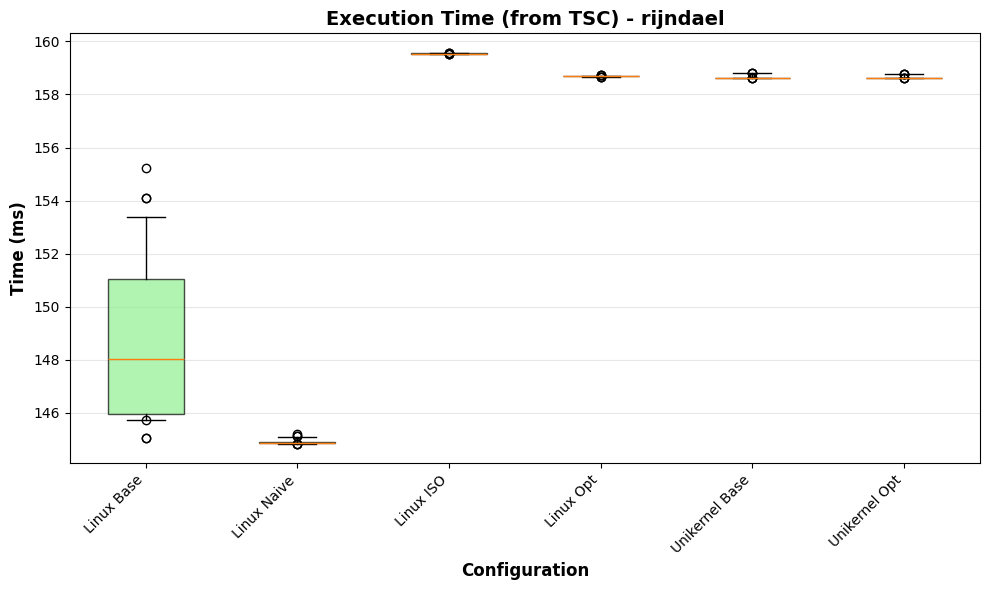


Coefficient of Variation (CV) for Execution Time


Configuration  Linux Base  Linux Naive  Linux ISO  Linux Opt  Unikernel Base  Unikernel Opt
Benchmark                                                                                  
crc32            0.299624     0.689909   0.012889   0.069264        0.046070       0.037353
cubic            0.108265     0.051843   0.011006   0.052263        0.050443       0.039588
dijkstra         2.014099     0.217970   0.132662   0.371284        0.069864       0.090500
fdct             0.751032     0.100542   0.020239   0.011268        0.046725       0.038803
fir              0.389282     0.069518   0.030743   0.031394        0.057744       0.041049
matmult-float    1.591303     0.059749   0.120430   0.017221        0.262151       0.221665
matmult-int      2.237339     0.079688   0.964126   0.264138        0.246137       0.167225
nettle-sha256    1.846143     0.116833   0.085288   0.076179        0.078600       0.072408
rijndael         1.909851   

In [22]:
# Boxplot for execution time per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'base_linux',
    'naive_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            # Calculate time in ms from cpu_cycles using base frequency of 3.1 GHz
            # time (ms) = cycles / (3.1 × 10^9 Hz) × 1000 = cycles / 3.1e6
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            data_to_plot.append(time_ms)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightgreen')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Time (ms)', fontsize=12, fontweight='bold')
        ax.set_title(f'Execution Time (from TSC) - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

# Calculate and display CV table for execution time
print("\n" + "="*80)
print("Coefficient of Variation (CV) for Execution Time")
print("="*80)

time_cv_results = []

for config_name in configs:
    if config_name not in pc_data:
        continue
    
    pc_df = pc_data[config_name]
    
    for benchmark in benchmarks:
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 1:
            # Calculate time in ms from cpu_cycles
            time_ms = pc_bench['cpu_cycles'].values / 3.1e6
            time_cv = (time_ms.std() / time_ms.mean()) * 100
        else:
            time_cv = None
        
        time_cv_results.append({
            'Configuration': config_labels.get(config_name, config_name),
            'Benchmark': benchmark,
            'CV (%)': time_cv
        })

# Convert to DataFrame and pivot for better display
time_cv_df = pd.DataFrame(time_cv_results)
time_cv_pivot = time_cv_df.pivot(index='Benchmark', columns='Configuration', values='CV (%)')

# Reorder columns to match config_order
display_order = [config_labels.get(c, c) for c in configs if config_labels.get(c, c) in time_cv_pivot.columns]
time_cv_pivot = time_cv_pivot[display_order]

print("\n")
print(time_cv_pivot.to_string())
print("\n" + "="*80)

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


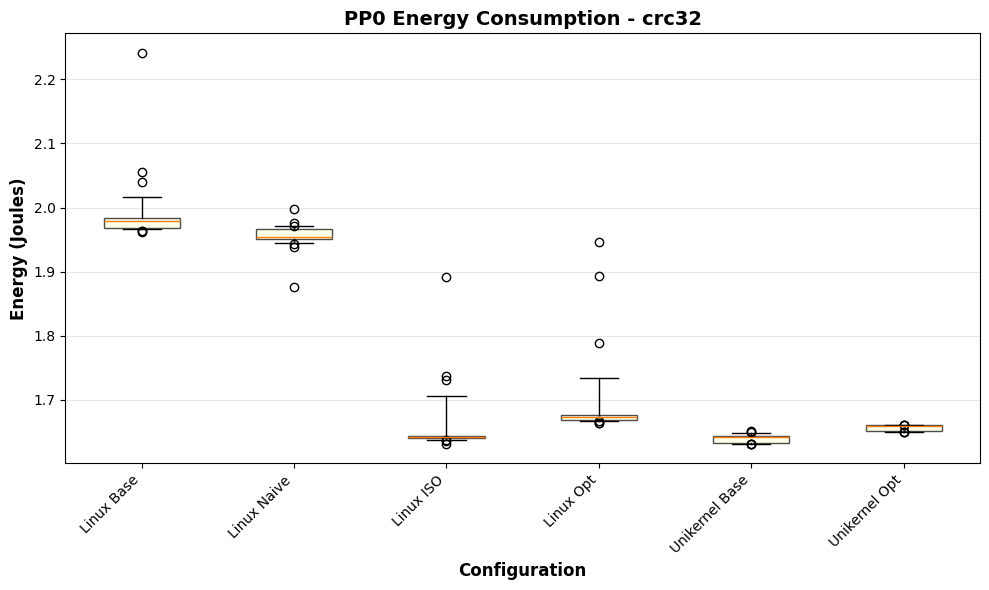

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


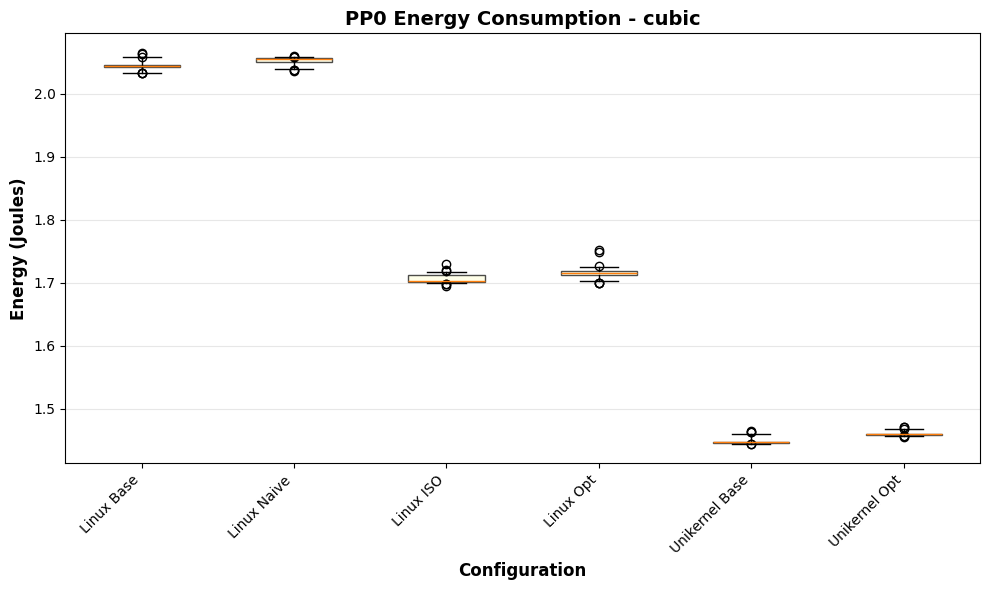

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


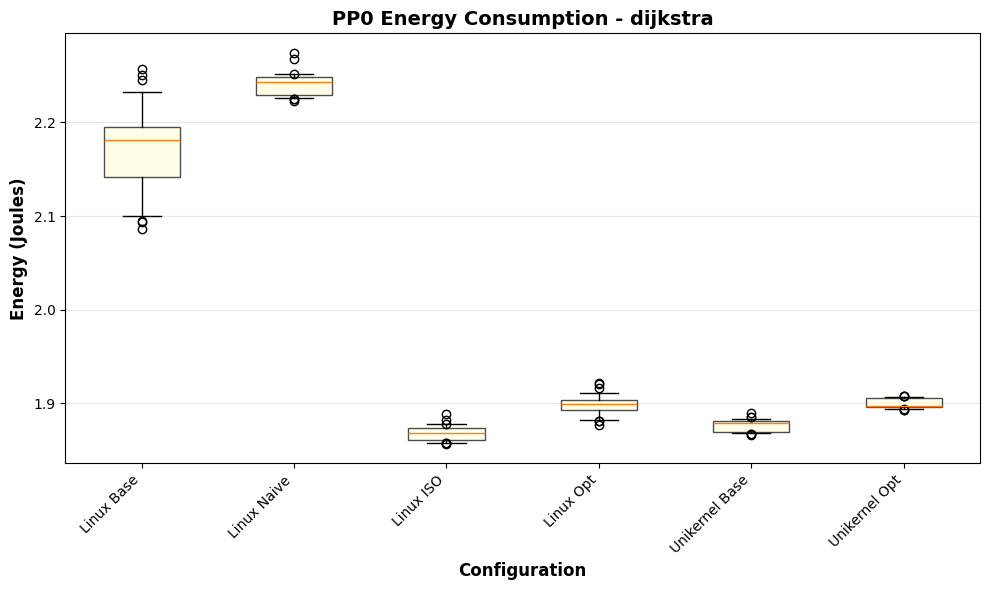

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


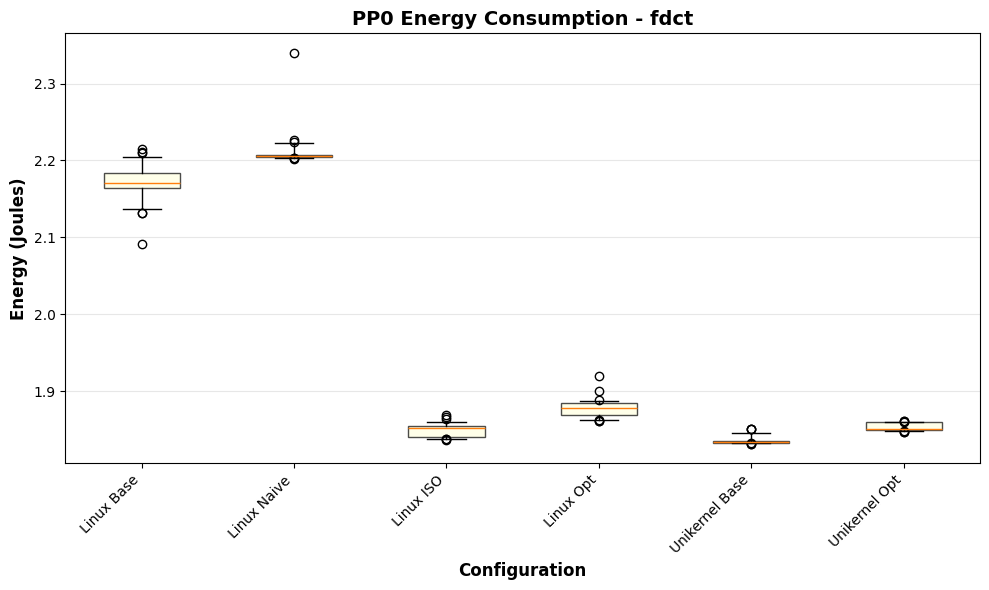

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


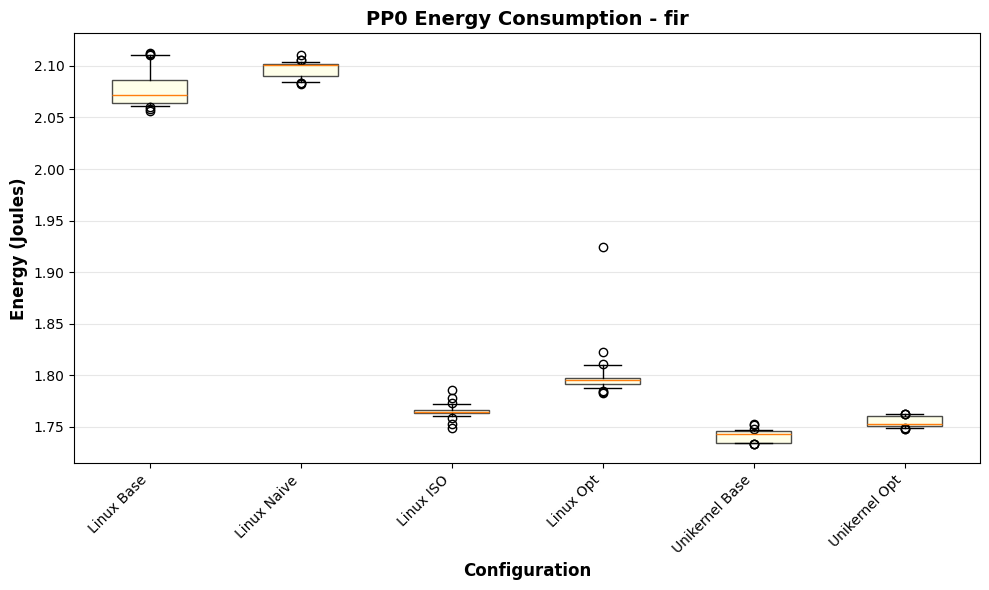

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


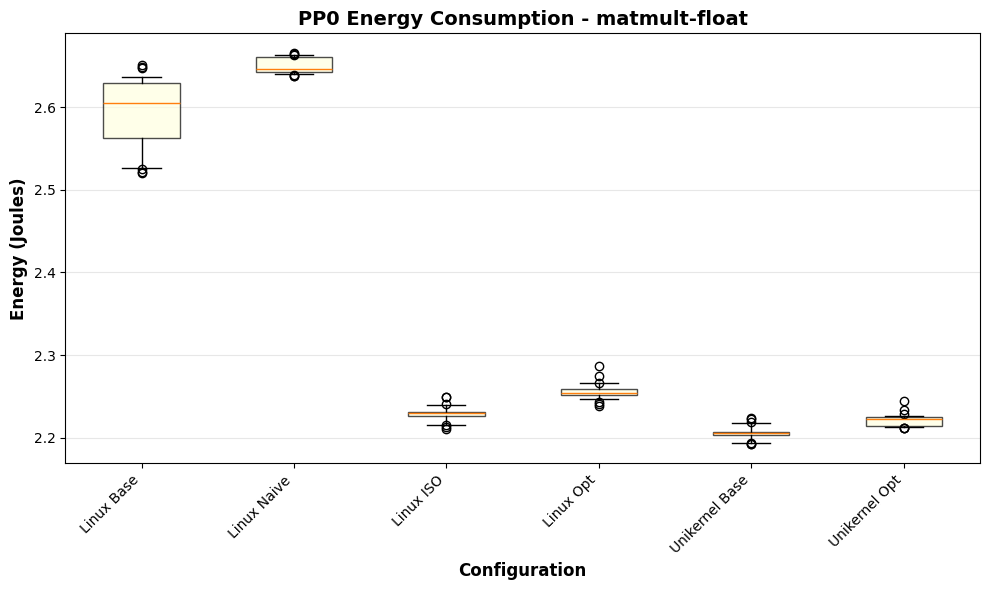

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


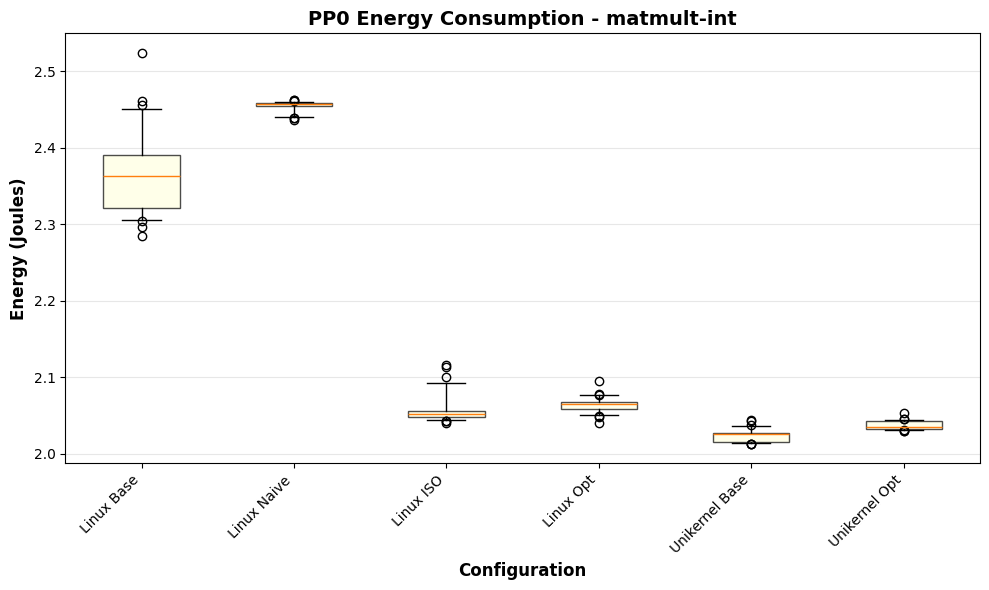

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


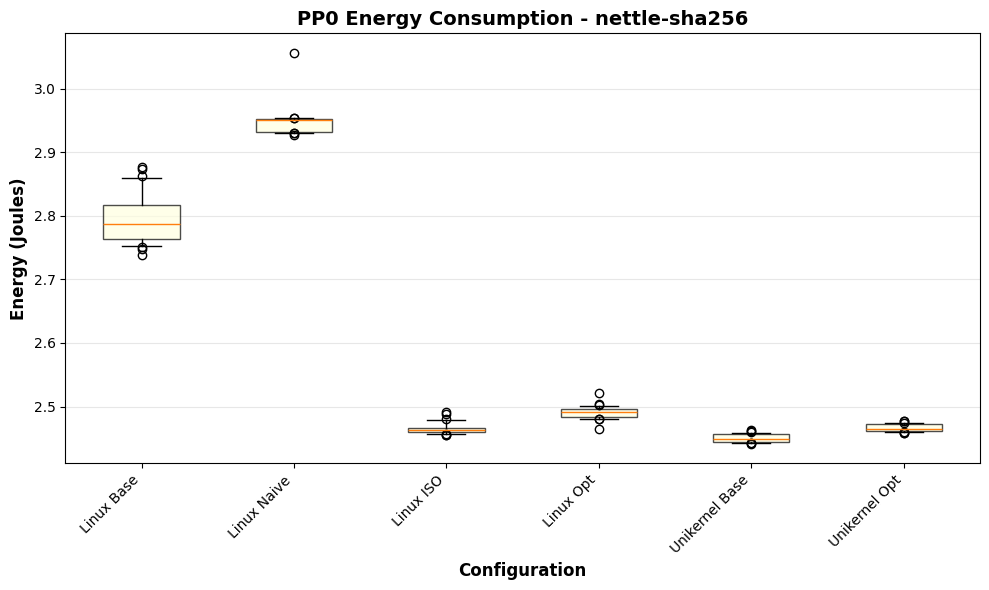

/var/folders/kr/cgw06xgj3j3gl_yslwcqy0x00000gn/T/ipykernel_45306/282656285.py:39: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))


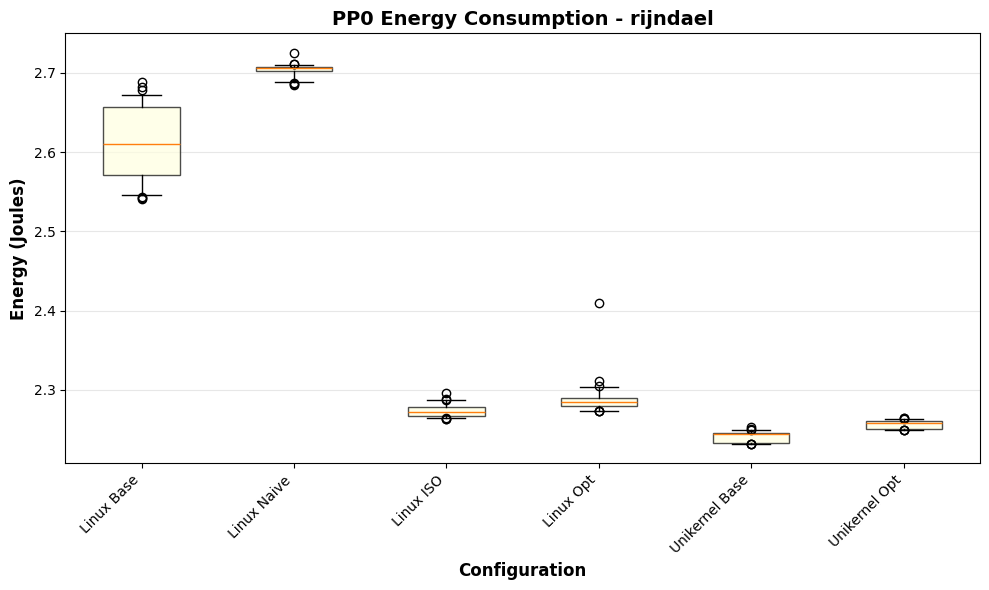

In [23]:
# Boxplot for PP0 energy consumption per benchmark
# One plot per benchmark, showing all configurations

# Get unique benchmarks
benchmarks = sorted([b for b in energy_df['benchmark'].unique() if pd.notna(b)])

# Define config order
config_order = [
    'base_linux',
    'naive_linux',
    'linux_iso',
    'linux_optimized_wo_iso',
    'base_unikernel',
    'optimized_unikernel'
]
configs = [c for c in config_order if c in subdirs.keys()]

# Create one plot for each benchmark
for benchmark in benchmarks:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Prepare data for boxplot - one box per configuration
    data_to_plot = []
    labels = []
    
    for config_name in configs:
        if config_name not in pc_data:
            continue
        
        pc_df = pc_data[config_name]
        pc_bench = pc_df[pc_df['benchmark'] == benchmark]
        
        if len(pc_bench) > 0:
            data_to_plot.append(pc_bench['pp0_joules'].values)
            labels.append(config_labels.get(config_name, config_name))
    
    # Create boxplot
    if data_to_plot:
        bp = ax.boxplot(data_to_plot, labels=labels, patch_artist=True, whis=(5, 95))
        
        # Customize boxplot appearance
        for patch in bp['boxes']:
            patch.set_facecolor('lightyellow')
            patch.set_alpha(0.7)
        
        ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
        ax.set_ylabel('Energy (Joules)', fontsize=12, fontweight='bold')
        ax.set_title(f'PP0 Energy Consumption - {benchmark}', fontsize=14, fontweight='bold')
        ax.tick_params(axis='x', rotation=45)
        plt.xticks(rotation=45, ha='right')
        ax.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()

In [24]:
# Calculate total execution time for each configuration
print("Total execution time per configuration:")
print("=" * 60)

for config_name in subdirs.keys():
    if config_name not in pc_data:
        print(f"{config_name}: No data available")
        continue
    
    pc_df = pc_data[config_name]
    
    # Sum all execution times
    total_time_ms = pc_df['cooldown_ms'].sum()
    total_time_s = total_time_ms / 1000
    total_time_min = total_time_s / 60
    
    # Count number of measurements
    num_measurements = len(pc_df)
    
    print(f"\n{config_name}:")
    print(f"  Total time: {total_time_ms:,.2f} ms ({total_time_s:,.2f} s / {total_time_min:,.2f} min)")
    print(f"  Number of measurements: {num_measurements}")
    print(f"  Average time per measurement: {total_time_ms/num_measurements:.2f} ms")

Total execution time per configuration:

base_linux:
  Total time: 8,213.08 ms (8.21 s / 0.14 min)
  Number of measurements: 451
  Average time per measurement: 18.21 ms

base_unikernel:
  Total time: 0.00 ms (0.00 s / 0.00 min)
  Number of measurements: 450
  Average time per measurement: 0.00 ms

naive_linux:
  Total time: 0.00 ms (0.00 s / 0.00 min)
  Number of measurements: 450
  Average time per measurement: 0.00 ms

linux_iso:
  Total time: 169.13 ms (0.17 s / 0.00 min)
  Number of measurements: 450
  Average time per measurement: 0.38 ms

linux_optimized_wo_iso:
  Total time: 788.84 ms (0.79 s / 0.01 min)
  Number of measurements: 450
  Average time per measurement: 1.75 ms

optimized_unikernel:
  Total time: 4,070.00 ms (4.07 s / 0.07 min)
  Number of measurements: 450
  Average time per measurement: 9.04 ms
